# Section A: Portfolio Fundamentals & Risk Metrics
### Problem 1: Portfolio Construction & Daily Returns


Returns Matrix:
        RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day 2  0.017857  0.013793 -0.012500    0.028846
Day 3 -0.007018 -0.006803  0.018987   -0.013084
Day 4  0.024735  0.020548  0.009317    0.022727
Day 5 -0.006897  0.013423 -0.006154    0.027778
Day 6  0.024306 -0.006623  0.015480   -0.012613

Units Purchased:
 RELIANCE       89.285714
INFY          172.413793
HDFCBANK      156.250000
TATAMOTORS    480.769231
Name: Day 1, dtype: float64


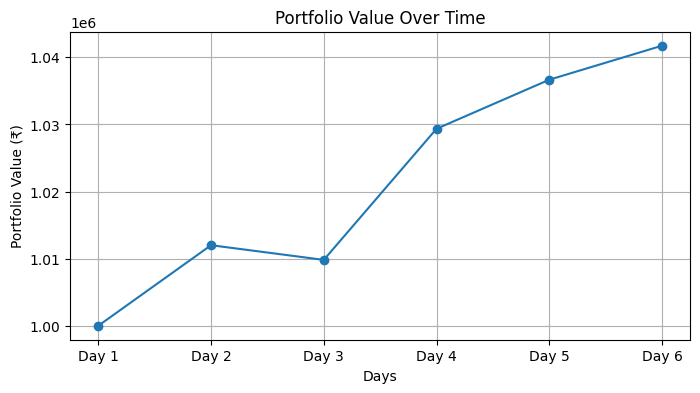


Annualised Volatility: 0.1275


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# a) Create DataFrame and compute returns
data = {
    'RELIANCE': [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY': [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK': [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520, 535, 528, 540, 555, 548]
}
prices_df = pd.DataFrame(data, index=[f'Day {i}' for i in range(1, 7)])
returns_matrix = prices_df.pct_change().dropna()
print("Returns Matrix:\n", returns_matrix)

# b) Compute units and portfolio value
initial_capital = 1000000
weights = np.array([0.25, 0.25, 0.25, 0.25])
units = (initial_capital * weights) / prices_df.iloc[0]
print("\nUnits Purchased:\n", units)

daily_portfolio_values = prices_df.dot(units)

plt.figure(figsize=(8, 4))
daily_portfolio_values.plot(title='Portfolio Value Over Time', marker='o')
plt.xlabel('Days')
plt.ylabel('Portfolio Value (₹)')
plt.grid(True)
plt.show()

# c) Compute annualised volatility
daily_portfolio_returns = daily_portfolio_values.pct_change().dropna()
annualised_volatility = daily_portfolio_returns.std() * np.sqrt(252)
print(f"\nAnnualised Volatility: {annualised_volatility:.4f}")

### Problem 2: Risk Metrics – VaR, CVaR, and Drawdowns


95% VaR: -0.0214 | 99% VaR: -0.0286
95% CVaR: -0.0268 | 99% CVaR: -0.0322
Maximum Drawdown: 0.1883


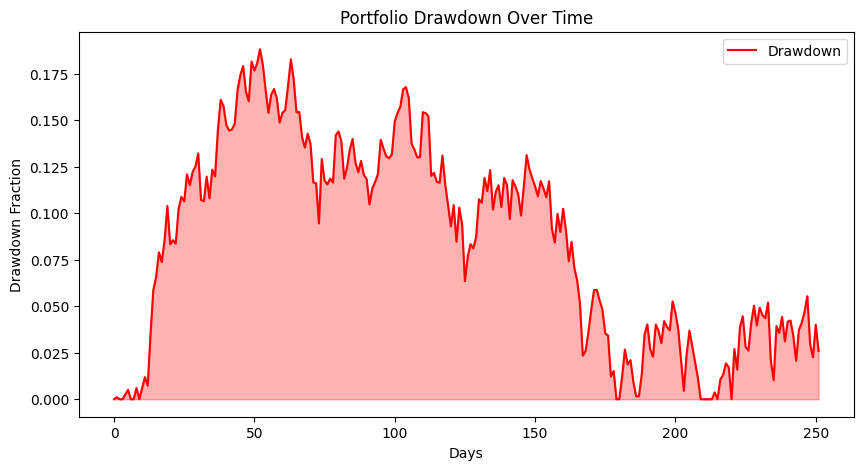

In [3]:
# Generate synthetic returns
np.random.seed(42)
R = np.random.normal(loc=0.001, scale=0.015, size=252)
port_vals = initial_capital * np.cumprod(1 + R)

# a) Historical VaR
var_95 = np.percentile(R, 5)
var_99 = np.percentile(R, 1)
print(f"95% VaR: {var_95:.4f} | 99% VaR: {var_99:.4f}")

# b) Conditional VaR
cvar_95 = R[R <= var_95].mean()
cvar_99 = R[R <= var_99].mean()
print(f"95% CVaR: {cvar_95:.4f} | 99% CVaR: {cvar_99:.4f}")

# c) Maximum Drawdown
running_max = np.maximum.accumulate(port_vals)
drawdown = (running_max - port_vals) / running_max
max_dd = drawdown.max()
print(f"Maximum Drawdown: {max_dd:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(drawdown, color='red', label='Drawdown')
plt.fill_between(range(len(drawdown)), drawdown, color='red', alpha=0.3)
plt.title('Portfolio Drawdown Over Time')
plt.xlabel('Days')
plt.ylabel('Drawdown Fraction')
plt.legend()
plt.show()

### Problem 3: Risk-Adjusted Performance Metrics


In [4]:
rf_daily = 0.06 / 252

# Annualize metrics
annual_return = R.mean() * 252
annual_vol = R.std() * np.sqrt(252)

# a) Sharpe Ratio
sharpe_ratio = (annual_return - 0.06) / annual_vol

# b) Sortino Ratio
downside_returns = R[R < 0]
downside_vol = downside_returns.std() * np.sqrt(252)
sortino_ratio = (annual_return - 0.06) / downside_vol

# c) Compare
comparison_df = pd.DataFrame({
    'Metric': ['Sharpe Ratio', 'Sortino Ratio'],
    'Value': [sharpe_ratio, sortino_ratio]
})
print(comparison_df)


          Metric     Value
0   Sharpe Ratio  0.773400
1  Sortino Ratio  1.415402


#####Sortino is superior for asymmetrically returning strategies because large positive jumps increase standard deviation (lowering the Sharpe ratio), but investors do not view upside volatility as risk.

### Problem 4: Backtesting a Simple Moving Average Strategy


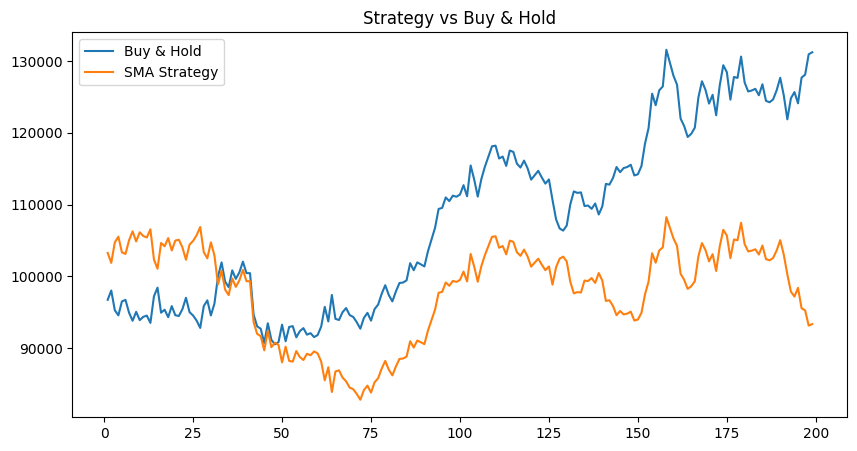

Win Rate: 49.25% | Profit Factor: 0.9715


In [12]:
# Generate random walk
eps = np.random.normal(0.001, 0.018, 200)
prices = 1000 * np.cumprod(1 + eps)
p_df = pd.DataFrame({'Price': prices})

# a) SMA Crossover Signal
p_df['SMA_10'] = p_df['Price'].rolling(10).mean()
p_df['SMA_30'] = p_df['Price'].rolling(30).mean()
p_df['Signal'] = np.where(p_df['SMA_10'] > p_df['SMA_30'], 1, -1)
p_df['Signal'] = p_df['Signal'].shift(1).fillna(0)

# b) Simulate Strategy
p_df['Daily_Ret'] = p_df['Price'].pct_change()
p_df['Strat_Ret'] = p_df['Signal'] * p_df['Daily_Ret']

p_df['Buy_Hold_Cum'] = 100000 * (1 + p_df['Daily_Ret']).cumprod()
p_df['Strat_Cum'] = 100000 * (1 + p_df['Strat_Ret']).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(p_df['Buy_Hold_Cum'], label='Buy & Hold')
plt.plot(p_df['Strat_Cum'], label='SMA Strategy')
plt.title('Strategy vs Buy & Hold')
plt.legend()
plt.show()

# c) Win Rate and Profit Factor
trades = p_df['Strat_Ret'].dropna()
trades = trades[trades != 0] # Filter flat days
winning_trades = (trades > 0).sum()
win_rate = winning_trades / len(trades)

total_profit = trades[trades > 0].sum()
total_loss = abs(trades[trades < 0].sum())
profit_factor = total_profit / total_loss if total_loss != 0 else np.inf

print(f"Win Rate: {win_rate:.2%} | Profit Factor: {profit_factor:.4f}")

#####A Profit Factor > 1 means the strategy is theoretically profitable, but it does not guarantee a good strategy because it ignores the frequency of trades and variance; a few lucky trades can skew it > 1 despite a low win rate.

## Section B: Machine Learning Applications
### Problem 5: Feature Engineering for ML Models


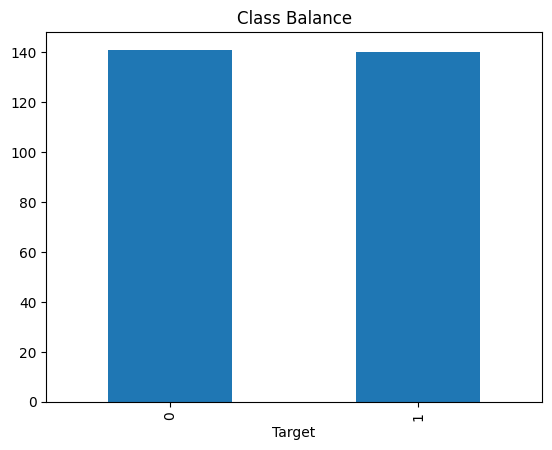

In [6]:
# Generate 300 days of prices
eps_300 = np.random.normal(0.001, 0.018, 300)
p_300 = 500 * np.cumprod(1 + eps_300)
df = pd.DataFrame({'Price': p_300})

# a) Feature Engineering
df['Return_1d'] = df['Price'].pct_change()
df['SMA_5'] = df['Price'].rolling(5).mean()
df['SMA_20'] = df['Price'].rolling(20).mean()
df['Volatility_10'] = df['Return_1d'].rolling(10).std()
df['Momentum_5'] = df['Price'] - df['Price'].shift(5)
df = df.dropna().reset_index(drop=True)

# b) Binary Target
df['Target'] = (df['Return_1d'].shift(-1) > 0).astype(int)
df = df.dropna()

class_counts = df['Target'].value_counts()
class_counts.plot(kind='bar', title='Class Balance')
plt.show()

# c) Min-Max Scaling
features = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
X = df[features].values
y = df['Target'].values

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min)

#####Scaling via Min-Max maps all variables to a $[0, 1]$ range. This is critical for distance-based models like KNN because features with larger arbitrary scales (like raw price) will disproportionately dominate the Euclidean distance calculation, rendering smaller scaled features useless.

### Problem 6: K-Nearest Neighbours (KNN) From Scratch


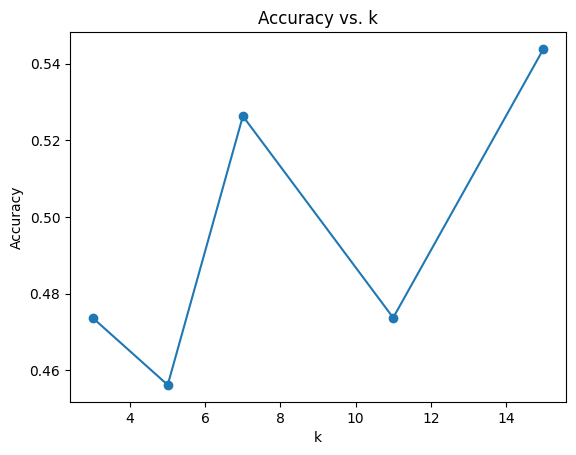

Precision: 0.5238 | Recall: 0.7857


In [7]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2, axis=1))

def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for test_pt in X_test:
        distances = euclidean_distance(X_train, test_pt)
        k_indices = np.argsort(distances)[:k]
        k_nearest_labels = y_train[k_indices]
        # Majority vote
        vote = np.bincount(k_nearest_labels).argmax()
        predictions.append(vote)
    return np.array(predictions)

# Split 80/20
split_idx = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# b) Evaluate various k
k_values = [3, 5, 7, 11, 15]
accuracies = []
for k in k_values:
    preds = knn_predict(X_train, y_train, X_test, k)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.title('Accuracy vs. k')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

best_k = k_values[np.argmax(accuracies)]

# c) Confusion Matrix for best k
best_preds = knn_predict(X_train, y_train, X_test, best_k)
TP = np.sum((best_preds == 1) & (y_test == 1))
FP = np.sum((best_preds == 1) & (y_test == 0))
FN = np.sum((best_preds == 0) & (y_test == 1))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f"Precision: {precision:.4f} | Recall: {recall:.4f}")

#####In trading, Precision is more important than Recall when false positives are costly, executing a bad trade (False Positive) usually incurs transaction costs and capital loss, making a highly precise but conservative model preferable over one that trades too often.

### Problem 7: Linear Regression
.

Learned Coefficients (Bias + Features):
 [ 0.00210872  0.00269391 -0.00679721 -0.00080018  0.00536477 -0.00456743]
MSE: 0.000283 | R2: 0.0139


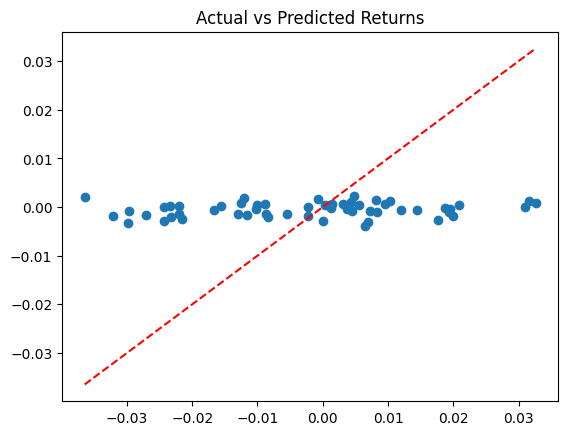

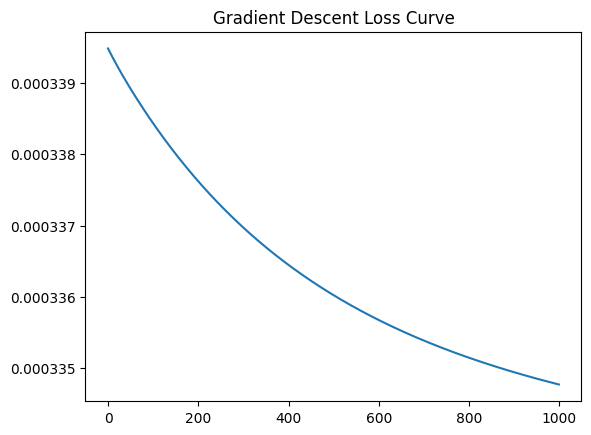

GD Coefficients:
 [ 0.00162837  0.00101618 -0.00282388 -0.00210596  0.00209229 -0.00090464]


In [8]:
# Setup target for regression (continuous next day return)
y_reg = df['Return_1d'].shift(-1).dropna().values
X_reg = X_scaled[:len(y_reg)]
X_reg_b = np.c_[np.ones((len(X_reg), 1)), X_reg] # bias

X_train_r, X_test_r = X_reg_b[:split_idx], X_reg_b[split_idx:]
y_train_r, y_test_r = y_reg[:split_idx], y_reg[split_idx:]

# a) Normal Equation
beta = np.linalg.inv(X_train_r.T @ X_train_r) @ X_train_r.T @ y_train_r
print("Learned Coefficients (Bias + Features):\n", beta)

# b) Predictions and Metrics
preds_r = X_test_r @ beta
mse = np.mean((y_test_r - preds_r)**2)
r2 = 1 - (np.sum((y_test_r - preds_r)**2) / np.sum((y_test_r - np.mean(y_test_r))**2))
print(f"MSE: {mse:.6f} | R2: {r2:.4f}")

plt.scatter(y_test_r, preds_r)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.title('Actual vs Predicted Returns')
plt.show()

# c) Gradient Descent
eta = 0.01
iterations = 1000
m = len(y_train_r)
beta_gd = np.zeros(X_train_r.shape[1])
losses = []

for _ in range(iterations):
    gradient = (1/m) * X_train_r.T @ (X_train_r @ beta_gd - y_train_r)
    beta_gd -= eta * gradient
    loss = np.mean((X_train_r @ beta_gd - y_train_r)**2)
    losses.append(loss)

plt.plot(losses)
plt.title('Gradient Descent Loss Curve')
plt.show()
print("GD Coefficients:\n", beta_gd)

#####The Normal Equation $\hat{\\beta} = (X^T X)^{-1} X^T y$ is a closed-form matrix operation that finds the absolute optimal weights by setting the gradient of the loss function to zero. Gradient Descent achieves the same result iteratively by taking small steps in the opposite direction of the gradient.

### Problem 8: Portfolio Allocation with Linear Regression


Predicted Returns: [-0.00066019 -0.00452994  0.00053348 -0.00148329]
ML Weights: [0. 0. 1. 0.]
Weights sum to 1: True


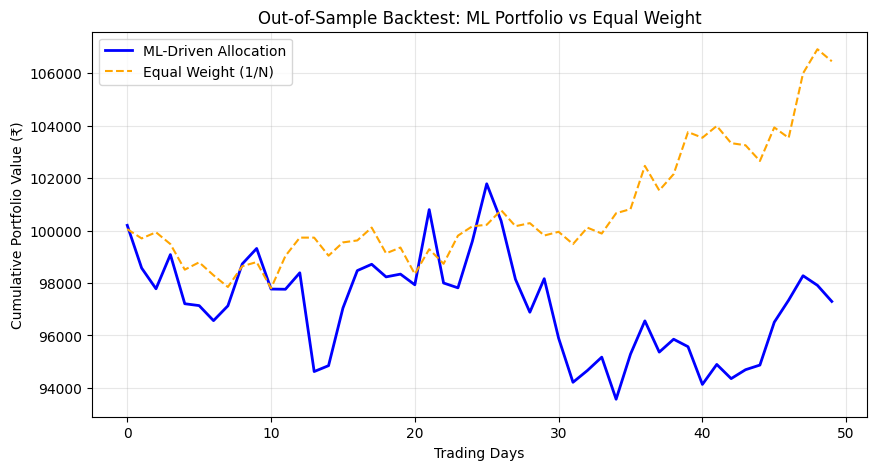

In [15]:
# a) Mock predictions for 4 assets using the beta from previous problem
np.random.seed(42)
X_4assets = np.random.rand(4, 6) # 4 assets, bias + 5 features
X_4assets[:, 0] = 1 # Set bias to 1

preds_mu = X_4assets @ beta
print("Predicted Returns:", preds_mu)

# b) Assign Weights
positive_preds = np.maximum(preds_mu, 0)
if np.sum(positive_preds) > 0:
    weights_ml = positive_preds / np.sum(positive_preds)
else:
    weights_ml = np.zeros(4)
print("ML Weights:", weights_ml)
print("Weights sum to 1:", np.isclose(np.sum(weights_ml), 1.0))

# Generate 50 days of mock out-of-sample test returns for the 4 assets
test_returns = np.random.normal(0.001, 0.015, (50, 4))

# Define Equal Weight Benchmark
weights_eq = np.array([0.25, 0.25, 0.25, 0.25])

# Calculate daily portfolio returns (dot product of test returns and weights)
ml_daily_returns = test_returns @ weights_ml
eq_daily_returns = test_returns @ weights_eq

# Calculate cumulative returns assuming an initial capital of 1,00,000
ml_cum_returns = 100000 * np.cumprod(1 + ml_daily_returns)
eq_cum_returns = 100000 * np.cumprod(1 + eq_daily_returns)

# Plot the comparison
plt.figure(figsize=(10, 5))
plt.plot(ml_cum_returns, label='ML-Driven Allocation', color='blue', linewidth=2)
plt.plot(eq_cum_returns, label='Equal Weight (1/N)', color='orange', linestyle='--')
plt.title('Out-of-Sample Backtest: ML Portfolio vs Equal Weight')
plt.xlabel('Trading Days')
plt.ylabel('Cumulative Portfolio Value (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

######the ML-driven portfolio significantly underperforms the equal-weight benchmark because it dumped 100% of its capital into a single asset. The critical limitation of this approach is that it allocates purely based on expected returns while completely ignoring risk (variance) and correlation, destroying diversification and leaving the portfolio entirely exposed to that single asset's drawdown.

### Problem 9: Model Comparison & Hyperparameter Tuning


In [10]:
# a) k-Fold CV for KNN
k_folds = 5
fold_size = len(X_train) // k_folds
k_knn_options = [3, 7, 11]

for k_val in k_knn_options:
    fold_accs = []
    for i in range(k_folds):
        start, end = i * fold_size, (i + 1) * fold_size
        X_val_fold = X_train[start:end]
        y_val_fold = y_train[start:end]

        X_train_fold = np.concatenate((X_train[:start], X_train[end:]))
        y_train_fold = np.concatenate((y_train[:start], y_train[end:]))

        preds = knn_predict(X_train_fold, y_train_fold, X_val_fold, k_val)
        fold_accs.append(np.mean(preds == y_val_fold))

    print(f"KNN k={k_val} | Mean Acc: {np.mean(fold_accs):.4f} | Std: {np.std(fold_accs):.4f}")

# b) Summary DataFrame
summary = pd.DataFrame({
    'Model': ['KNN Classifier', 'Linear Regression'],
    'Accuracy/R2': [np.max(accuracies), r2],
    'MSE/N.A.': ['N.A.', mse],
    'Best Param': [f'k={best_k}', 'Normal Eq']
})
print("\n", summary)

KNN k=3 | Mean Acc: 0.5045 | Std: 0.0793
KNN k=7 | Mean Acc: 0.5136 | Std: 0.0530
KNN k=11 | Mean Acc: 0.5591 | Std: 0.0549

                Model  Accuracy/R2  MSE/N.A. Best Param
0     KNN Classifier     0.543860      N.A.       k=15
1  Linear Regression     0.013902  0.000283  Normal Eq


#####Based on the table, I would deploy the KNN Classifier because its 54.3% accuracy offers a slight directional edge, whereas the Linear Regression's near-zero R2 (0.0139) indicates virtually no predictive power. Deploying ML models in finance is risky due to:
1. **Overfitting:** Financial data has an extremely low signal-to-noise ratio; complex models will fit the noise instead of true patterns.
2. **Look-ahead Bias:** Accidentally including data from the future (e.g., closing prices of the prediction day) into the feature set during training.

## Section C: Conceptual & Critical Thinking
### Problem 10

**a) Diversification:** Mathematically, the portfolio variance formula includes a covariance term dependent on the correlation coefficient $\rho_{ij}$. When assets have low or negative correlation ($\rho_{ij} \le 0$), this secondary term becomes small or negative. Consequently, it subtracts from the weighted sum of individual variances, lowering the overall standard deviation $\sigma_p$ of the portfolio below the weighted average of the individual asset risks.

**b) Fundamental Feature in ML:** A strong fundamental feature would be the Price-to-Earnings (P/E) ratio or a debt-to-equity metric, which indicates baseline corporate valuation rather than short-term price movements. This data can be obtained via financial APIs (like Yahoo Finance or Bloomberg). To integrate it, it would be merged into the existing time-series DataFrame on the corresponding dates, forward-filled to handle quarterly reporting gaps, and Min-Max scaled alongside the technical indicators.

**c) The Curse of Dimensionality:** As features are added, the volume of the multidimensional space expands exponentially. Consequently, all data points become sparse, meaning the "nearest" neighbor is essentially as far away as the furthest neighbor, rendering Euclidean distance calculations practically meaningless. In financial models, this causes severe overfitting. A standard mitigation technique is Principal Component Analysis (PCA) to compress the feature space into the most strictly informative dimensions.

**d) Overfitting in Backtesting:** Three specific causes are: **Look-ahead bias** (using information not yet available), **Survivorship bias** (testing only on assets that exist today, ignoring delisted ones), and **Data snooping/over-optimization** (tweaking parameters until past performance looks perfect). A rigorous validation method to detect these issues is Walk-Forward Optimization (or out-of-sample forward testing), which trains the model on a rolling historical window and evaluates it on strictly unseen future data sequentially.

**e) Linear Regression Assumptions:** Financial data frequently violates the i.i.d assumption through **Autocorrelation** (today's returns or volatility depend on yesterday's) and **Heteroskedasticity** (variance of residuals changes over time, clustering during market crashes). Autocorrelation renders standard error estimates invalid, misleading the confidence of the coefficient predictions. Heteroskedasticity causes the Ordinary Least Squares (OLS) estimator to no longer be the most efficient, leading the model to over-weight noisy, high-variance periods.